### <center> Задача II: И снова алгоритм Хаффмана <center>

Задачи

1. Подготовка к экспериментам.
* Реализуйте код Хаффмана для n-грам (алфавит кодера считать бинарным). Вы можете сделать либо два класса (разделить кодер и декодер), либо один общий класс; в обоих случаях ваша реализация должна следовать протоколам Encoder и Decoder (см. документацию). В случае если длина кодируемого текста не кратна, текст нужно дополнить специальным символом до длины кратной 
* Определите набор метрик, которые будут сниматься в результате работы алгоритма, и набор переменных, влияние которых будет исследоваться. Обоснуйте свой выбор.
2. Подготовка валидационных данных.
* Определите количество наборов, число символов и их распределение в каждом наборе, размер набора. Обоснуйте выбор (вам может потребоваться предварительный эксперимент; если так, его также стоит включить в решение). Используйте класс ProbabilisticSender, чтобы сгенерировать предложенные наборы; зафиксируйте seed генерации.
3. Анализ на синтетических данных.
* Проведите эксперименты на сгенерированных наборах, варьируя выбранные в п.1 переменные.
* Постройте графики зависимости метрик от переменных.
* Проанализируйте полученные результаты. Сравните с теоретическими ожиданиями.
4. Подготовка реальных данных
* Определите набор реальных данных для анализа. Обоснуйте выбор: чем интересен именно этот набор, какие зависимости вы ожидаете увидеть.
* Подготовьте данные к использованию (при необходимости).
5. Анализ на реальных данных
* Примените реализованный алгоритм к реальным данным.
* Сравните результаты с синтетическими экспериментами.
* Оцените эффективность сжатия: достигнутая степень сжатия, скорость работы, влияние размера блока.
* Сделайте выводы

Определим набор метрик для оценки эффективности кодирования:  
1) Средняя длина кода на 1 символ (expected_code_length_per_symbol)  -- сравнение со средней длиной кода при побуквенном кодировании позволит оценить эффективность увеличения длины блоков
2) Энтропия на 1 символ (entropy_per_symbol) -- позволит определить насколько наш код близок к оптимальному
3) Эффективность кодирования


Переменные для исследования:

1. Размер блока -- основная исследуемая величина. Хотим проверить гипотезу, что с ростом 
 растет эффективность алгоритма.
2. Длина текста
3. Закон распределения вероятностей -- при разных распределениях, кодирование будет работать по-разному. Цель — подтвердить или опровергнуть, что увеличение размера блока дает выигрыш в эффективности независимо от вида распределения вероятностей символов

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict


from ngram_huffman import NGramHuffmanEncoder

In [ ]:
""" Равновероятные символы"""
uniform_probs = OrderedDict([("a", 0.25), ("b", 0.25), ("c", 0.25), ("d", 0.25)])

""" Один частый символ"""

one_probs = OrderedDict([("a", 0.7), ("b", 0.1), ("c", 0.1), ("d", 0.1)])


"""Реальное распределение символов в русском языке"""

russian_probs = OrderedDict(
    [
        ("о", 0.11),
        ("е", 0.09),
        ("а", 0.08),
        ("и", 0.07),
        ("н", 0.07),
        ("т", 0.06),
        ("с", 0.05),
        ("р", 0.05),
        ("в", 0.04),
        ("л", 0.04),
    ]
)


current_sum = sum(russian_probs.values())


russian_probs = OrderedDict(
    [
        ("о", 0.11 / current_sum),
        ("е", 0.09 / current_sum),
        ("а", 0.08 / current_sum),
        ("и", 0.07 / current_sum),
        ("н", 0.07 / current_sum),
        ("т", 0.06 / current_sum),
        ("с", 0.05 / current_sum),
        ("р", 0.05 / current_sum),
        ("в", 0.04 / current_sum),
        ("л", 0.04 / current_sum),
    ]
)

Длина 100, эффективность=0.9770
Длина 500, эффективность=0.9867
Длина 1000, эффективность=0.9887
Длина 5000, эффективность=0.9989
Длина 10000, эффективность=0.9990
Длина 50000, эффективность=0.9940
Длина 100000, эффективность=0.9945


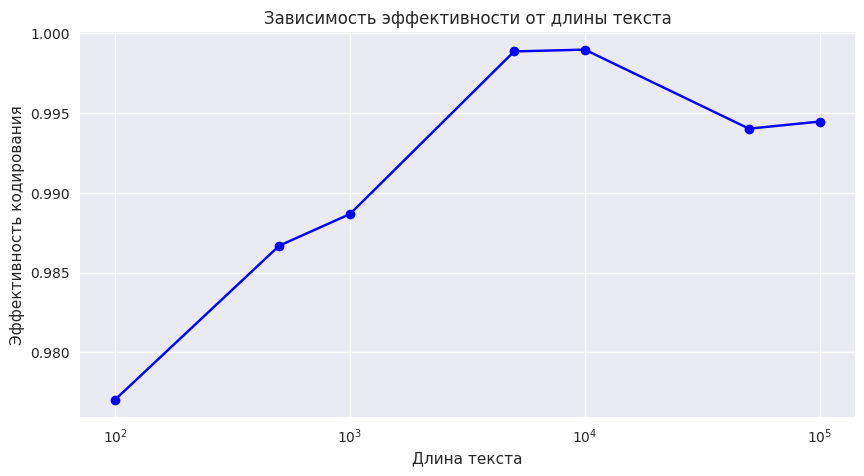

In [24]:
from collections import OrderedDict

test_probs = OrderedDict([("a", 0.25), ("b", 0.25), ("c", 0.25), ("d", 0.25)])

lengths = [100, 500, 1000, 5000, 10000, 50000, 100000]
results = []

np.random.seed(42)

for length in lengths:
    symbols = list(test_probs.keys())
    probs = list(test_probs.values())
    text = "".join(np.random.choice(symbols, size=length, p=probs))

    encoder = NGramHuffmanEncoder(n=10)
    encoder.build_from_text(text)

    efficiency = encoder.coding_efficiency
    results.append({"length": length, "efficiency": efficiency})

    print(f"Длина {length}, эффективность={efficiency:.4f}")


plt.figure(figsize=(10, 5))
lengths = [r["length"] for r in results]
efficiencies = [r["efficiency"] for r in results]

plt.plot(lengths, efficiencies, "bo-")
plt.xscale("log")
plt.xlabel("Длина текста")
plt.ylabel("Эффективность кодирования")
plt.title("Зависимость эффективности от длины текста")
plt.grid(True)
plt.show()

Длина 100, эффективность=0.9874
Длина 500, эффективность=0.9926
Длина 1000, эффективность=0.9930
Длина 5000, эффективность=0.9994
Длина 10000, эффективность=0.9996
Длина 50000, эффективность=0.9999
Длина 100000, эффективность=0.9999


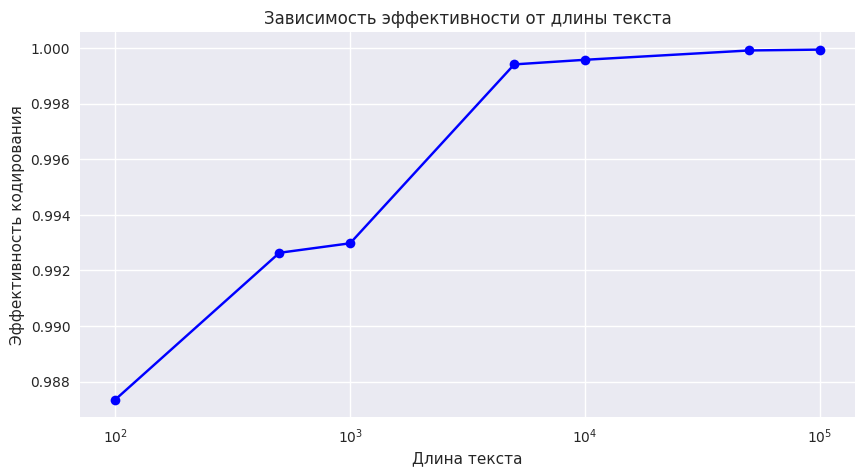

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from ngram_huffman import NGramHuffmanEncoder

test_probs = OrderedDict([("a", 0.25), ("b", 0.25), ("c", 0.25), ("d", 0.25)])

lengths = [100, 500, 1000, 5000, 10000, 50000, 100000]
results = []

np.random.seed(42)

for length in lengths:
    symbols = list(test_probs.keys())
    probs = list(test_probs.values())
    text = "".join(np.random.choice(symbols, size=length, p=probs))

    encoder = NGramHuffmanEncoder(n=2)
    encoder.build_from_text(text)

    efficiency = encoder.coding_efficiency
    results.append({"length": length, "efficiency": efficiency})

    print(f"Длина {length}, эффективность={efficiency:.4f}")


plt.figure(figsize=(10, 5))
lengths = [r["length"] for r in results]
efficiencies = [r["efficiency"] for r in results]

plt.plot(lengths, efficiencies, "bo-")
plt.xscale("log")
plt.xlabel("Длина текста")
plt.ylabel("Эффективность кодирования")
plt.title("Зависимость эффективности от длины текста")
plt.grid(True)
plt.show()

Длина каждого текста — 10 000 символов: достаточно для устойчивой статистики, но не слишком много для расчётов

In [4]:
datasets = {"uniform": uniform_probs, "one_big": one_probs, "russian": russian_probs}


generated_texts = {}

np.random.seed(42)


# не получилось через ProbabilisticSender
for name, probs in datasets.items():
    symbols = list(probs.keys())
    probabilities = list(probs.values())

    text = "".join(np.random.choice(symbols, size=10000, p=probabilities))
    generated_texts[name] = text

    print(f"{name}: {len(text)} символов")
    print(f"  Первые 50: {text[:50]}")
    print()

uniform: 10000 символов
  Первые 50: bdccaaadccaddaaabcbbcabbbdaccacaadddbacbabadbcbcca

one_big: 10000 символов
  Первые 50: aaaaacaabbcbdaaaaaaaaadabadcaaadccaacaaadaaabaaabd

russian: 10000 символов
  Первые 50: сеатислотеаооаавслнеааатнаооеосотаорневоестеораеив

